## Notebook 2 — Regression Model Optimisation & Validation (Marketing Mix Dataset)

### 1. Loading Data and Initial Exploration

#### Importing libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler)
from sklearn.metrics import r2_score
from sklearn.model_selection import (train_test_split, cross_val_score, cross_val_predict, GridSearchCV, ShuffleSplit)
from sklearn.linear_model import LinearRegression

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#### Importing synthetic dataframe

In [7]:
df = pd.read_csv('Synthetic_Market_Dataframe.csv').drop('Unnamed: 0', axis = 1)

df.head()

,google_spend,meta_spend,tiktok_spend,linkedin_spend,email_spend,ctr,cpc,impressions,revenue,total_spend,google_share,meta_share
0,19352.465824,12112.247848,7472.816369,7495.053656,3676.991724,0.016466,5.286084,85720,313151.792321,50109.575421,0.386203,0.241715
1,47585.001014,14466.351952,6658.241925,11201.201588,1004.108778,0.014253,3.944693,1726885,354471.126119,80914.905256,0.588087,0.178785
2,36867.703149,25709.148099,3523.078250,8440.001710,1798.534502,0.052293,7.733739,4013815,436025.243627,76338.465711,0.482951,0.336778
3,30334.265726,10530.129389,12145.333402,1249.538747,3350.075121,0.077628,2.142338,2142314,252781.463673,57609.342384,0.526551,0.182785
4,8644.913382,26154.665702,9532.483210,2783.703552,2462.237788,0.045190,4.908923,4004822,298776.377299,49578.003634,0.174370,0.527546


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   google_spend    5000 non-null   float64
 1   meta_spend      5000 non-null   float64
 2   tiktok_spend    5000 non-null   float64
 3   linkedin_spend  5000 non-null   float64
 4   email_spend     5000 non-null   float64
 5   ctr             5000 non-null   float64
 6   cpc             5000 non-null   float64
 7   impressions     5000 non-null   int64  
 8   revenue         5000 non-null   float64
 9   total_spend     5000 non-null   float64
 10  google_share    5000 non-null   float64
 11  meta_share      5000 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 468.9 KB


In [12]:
df.isnull().sum()

google_spend      0
meta_spend        0
tiktok_spend      0
linkedin_spend    0
email_spend       0
ctr               0
cpc               0
impressions       0
revenue           0
total_spend       0
google_share      0
meta_share        0
dtype: int64

In [13]:
df.nunique()

google_spend      5000
meta_spend        5000
tiktok_spend      5000
linkedin_spend    5000
email_spend       5000
ctr               5000
cpc               5000
impressions       5000
revenue           5000
total_spend       5000
google_share      5000
meta_share        5000
dtype: int64

In [11]:
df.describe()

,google_spend,meta_spend,tiktok_spend,linkedin_spend,email_spend,ctr,cpc,impressions,revenue,total_spend,google_share,meta_share
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,25344.767559,14998.870169,10027.501070,7615.270498,2593.007861,0.044393,4.254607,2.512143e+06,325448.156958,60579.417156,0.396779,0.250853
std,14192.048904,8425.687025,5815.396355,4317.093267,1414.832211,0.019919,2.162441,1.430737e+06,70612.196321,18018.741849,0.173461,0.137207
min,1000.570103,501.558395,3.154892,3.786817,100.235807,0.010008,0.500042,1.175900e+04,94790.703480,9746.904138,0.017472,0.006983
25%,12949.277527,7790.804298,4943.346519,3940.939296,1368.589376,0.027300,2.356432,1.286755e+06,277657.886092,47204.818597,0.267347,0.147608
50%,25500.422653,14836.161434,9923.942667,7686.744586,2615.367868,0.044368,4.264259,2.506418e+06,328436.574863,60724.184819,0.421601,0.245865
75%,37656.942267,22134.462152,15212.380092,11266.583606,3812.713503,0.061251,6.111699,3.754201e+06,375647.414865,73834.257221,0.525111,0.338105
max,49986.165991,29985.403096,19996.102883,14998.872402,4999.514787,0.079981,7.998420,4.999780e+06,543448.282114,112790.680718,0.860357,0.826593


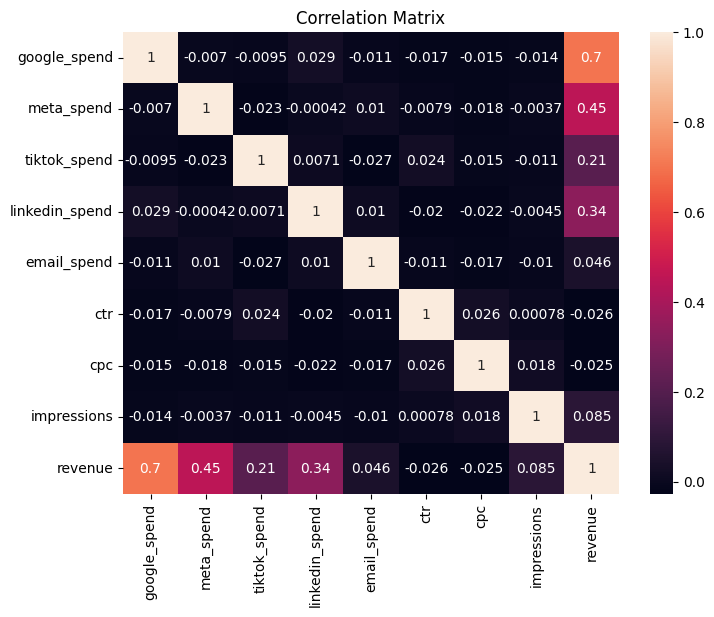

In [107]:
corr = df.drop(['total_spend','google_share', 'meta_share'], axis = 1).corr()

plt.figure(figsize = (8,6))
sns.heatmap(corr, annot = True)

plt.title('Correlation Matrix')
plt.show();

### 2. Feature Selection and Train/Test/Split

In [31]:
X = df.drop(['total_spend', 'revenue'], axis = 1)
# removing total_spend to prevent data leakage since it is the sum of individual channel spends

y = df['revenue']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 21)

print(f'The shape of X_train{X_train.shape} matches the shape of y_train{y_train.shape}, likewise the shape of X_test{X_test.shape} matches the shape of y_test{y_test.shape}.')

The shape of X_train(4000, 10) matches the shape of y_train(4000,), likewise the shape of X_test(1000, 10) matches the shape of y_test(1000,).


### 3. Baseline Linear Regression Pipeline

In [32]:
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_pipe.fit(X_train, y_train)

pred_linear = linear_pipe.predict(X_test)

In [44]:
r2_linear = r2_score(y_test,pred_linear)

print(f'The R2_Score for Linear Regression comes to {r2_linear:.4f}.')

The R2_Score for Linear Regression comes to 0.8681.


#### Actual vs Predicted Plot - Linear Regression

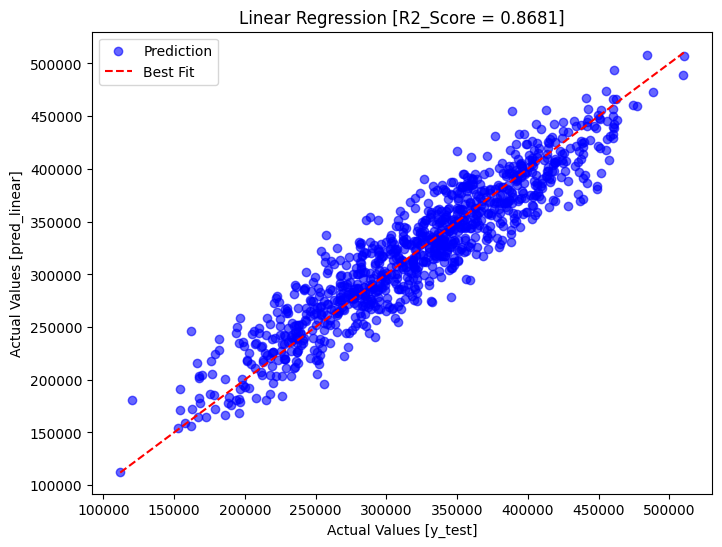

In [134]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, pred_linear, alpha = 0.6, color = 'blue', label = 'Prediction')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--', label = 'Best Fit')

plt.title(f'Linear Regression [R2_Score = {r2_linear:.4f}]')
plt.xlabel('Actual Values [y_test]')
plt.ylabel('Actual Values [pred_linear]')
plt.legend()
plt.show();

### 4. Polynomial Regression

In [47]:
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    # degeee = 2 - specifies the maximum power of the new features
    # include_bias = False - prevents calculating intercept (bias) or column filled with number 1
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly_pipe.fit(X_train, y_train)

pred_poly = poly_pipe.predict(X_test)

In [48]:
r2_poly = r2_score(y_test, pred_poly)

print(f'The R2_Score for Polynomial Regression comes to {r2_poly:.4f}.')

The R2_Score for Polynomial Regression comes to 0.8718.


**Observation** - Polynomial Regression provides marginally better (approx. 0.0037) R2_Score than Linear Regression.

#### Actual vs Predicted Plot - Polynomial Regression

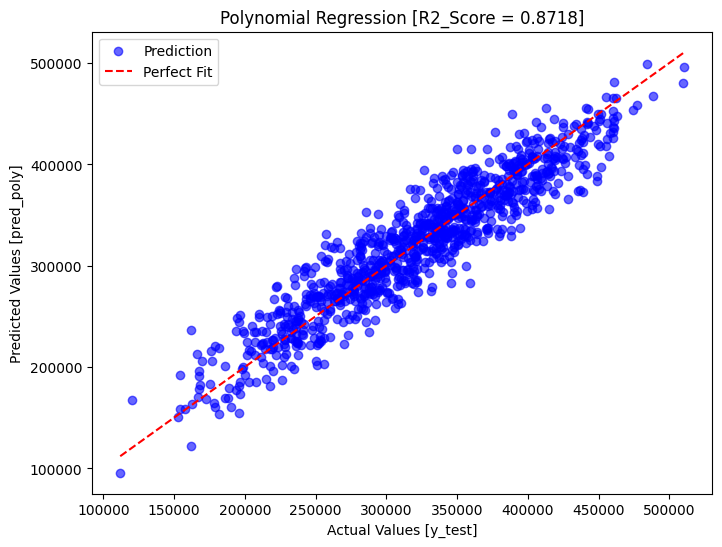

In [133]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, pred_poly, alpha = 0.6, color = 'blue', label = 'Prediction')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--', label = 'Perfect Fit')

plt.title(f'Polynomial Regression [R2_Score = {r2_poly:.4f}]')
plt.xlabel('Actual Values [y_test]')
plt.ylabel('Predicted Values [pred_poly]')
plt.legend()
plt.show();

### 5. K-Fold Cross Validation

In [86]:
scores_pp = cross_val_score(
    poly_pipe, X, y, cv = 5, scoring = 'r2'
)
# cv = 5 - specified the number of folds in dataset split
# scoring = 'r2' - to evaluate the model using R2_Score for each split

print(f'The Cross Validation Score via Poly_pipe comes to {np.round(scores,4)}.')
print(f'The mean score comes to {scores.mean():.4f}.')

The Cross Validation Score via Poly_pipe comes to [0.8721 0.8814 0.8652 0.8714 0.8759].
The mean score comes to 0.8732.


### 6. Degree Search Using Loops

In [68]:
results = []

for degreee in [1,2,3,4,5]:
    p_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree = degreee, include_bias = False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
    ])
    
    cvs = cross_val_score(
    p_pipe, X, y, cv = 5, scoring = 'r2'
    ).mean()

    results.append([degreee, cvs])

results_df = pd.DataFrame(results, columns = ['Degree', 'R2_Score'])

print(results_df)

   Degree  R2_Score
0       1  0.867115
1       2  0.873207
2       3  0.865449
3       4  0.813058
4       5 -2.341795


#### Degree Vs R2 Curve

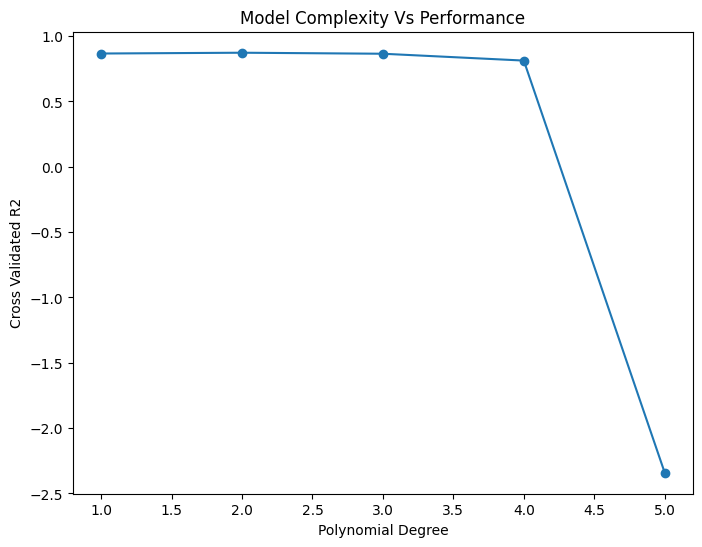

In [140]:
plt.figure(figsize = (8,6))

plt.plot(results_df['Degree'], results_df['R2_Score'], marker = 'o')

plt.title('Model Complexity Vs Performance')
plt.xlabel('Polynomial Degree')
plt.ylabel('Cross Validated R2')
plt.show();

### 7. Automated Tuning & Diagnostics

#### GridSearchCV

In [85]:
params = {
    'poly__degree':[1,2,3,4,5]
}

grid = GridSearchCV(
    poly_pipe, params, cv = 5, scoring = 'r2'
)

grid.fit(X_train, y_train)

print(f'The best parameters comes to {grid.best_params_}.')
print(f'The best score comes to {grid.best_score_:.4f}.')

The best parameters comes to {'poly__degree': 2}.
The best score comes to 0.8726.


#### ShuffleSplit

In [91]:
ss = ShuffleSplit(
    n_splits = 10,
    test_size = 0.2,
    random_state = 21
)

scores_grid = cross_val_score(
    grid.best_estimator_, X, y, cv = ss, scoring = 'r2'
)

print(f'The Cross Validation score via grid_best_estimator_ for 10 ShuffleSplit comes to \n{np.round(scores_grid, 4)}.')
print(f'The mean score comes to {scores_grid.mean():.4f}.')

The Cross Validation score via grid_best_estimator_ for 10 ShuffleSplit comes to 
[0.8718 0.8706 0.8596 0.8742 0.853  0.8706 0.8786 0.8765 0.8837 0.8758].
The mean score comes to 0.8715.


#### Cross Validation Predictions

In [106]:
predictions = cross_val_predict(
    grid.best_estimator_, X, y, cv = 5
)

residuals = y - predictions

print(pd.DataFrame(residuals.describe()))

            revenue
count   5000.000000
mean       0.527872
std    25124.300632
min   -91114.757190
25%   -17022.782818
50%      513.596539
75%    16624.756551
max    88876.757320


#### Residuals Vs Predictions

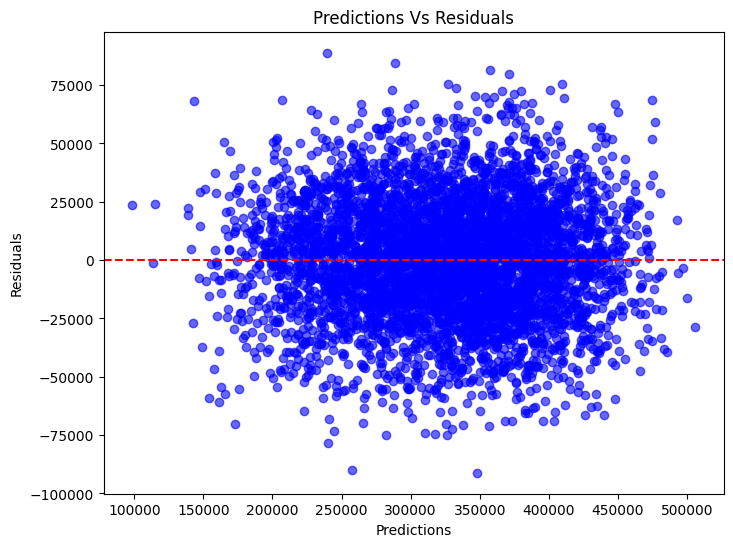

In [143]:
plt.figure(figsize = (8,6))

plt.scatter(predictions, residuals, alpha = 0.6, color = 'blue')

plt.axhline(y = 0, linestyle = '--', color = 'red')

plt.title('Predictions Vs Residuals')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show();